# Example figure: original vs archive-light

One VQA figure, unmodified on top and page-aged on the bottom, saved as a PDF
for the paper.

## Keeping it unpixelated

The source figures are already rasters, so the only thing this notebook can do
is avoid adding *more* pixelation on the way out. The setting that matters is
`interpolation='none'`. Measured on `vqa_000016` (3079x2115) into a 7-inch-wide
PDF at 300 dpi:

| setting | pixels embedded in the PDF |
|---|---|
| `interpolation='none'` | **3079 x 2115** -- the original, untouched |
| `interpolation='antialiased'` (matplotlib's default) | 2100 x 1443 -- resampled down |

With `'none'` the full image data goes into the PDF whatever the page size is,
and the viewer scales it at display time; matplotlib never resamples it. So the
figure can be a sensible width for a paper without throwing away resolution.
`resample=False` is set as well, and the PDF's own image compression is lossless
(Flate), so nothing is lost there either.

A native-resolution PNG is written alongside it, for anywhere a PDF is awkward.


In [21]:
# ============================ CONFIG ============================
# vqa_id = 'vqa_000133'          # which figure to show
# side_by_side = False
# label_corner     = 'upper left'
# label_inset      = 0.015
# label_xy         = None

vqa_id = 'vqa_000079'          # which figure to show
side_by_side = True
label_corner     = 'bottom left'
label_inset      = 0.015
label_xy         = None

# where the two versions live
clean_dir = '~/Dropbox/WASP2026/VQA/imgs/'
aged_dir  = '~/Dropbox/WASP2026/LMM_outputs_n150_archive_light/aged_imgs/'
img_format = 'jpeg'

# where it goes.  '{id}' in the name is replaced by vqa_id, if you want one file
# per figure rather than overwriting a single example.
fig_out_dir = '~/Dropbox/WASP2026/paper_figures/'
out_name    = 'example_images.pdf'

# panel labels; set to None for no labels at all
labels = ['original', 'archive-light']

# Make both panels the exact same size.  The aged canvas is a little larger --
# a rotation pads the page out -- so without this the two panels are different
# shapes, and drawing them at a common width puts them at slightly different
# scales.  With it, the smaller image is PADDED (not resized) out to the larger
# canvas, so both panels are identical rectangles at identical scale and no
# resampling happens anywhere.
match_panel_size = True
pad_color = (255, 255, 255)   # RGB, the colour of the padding

# layout -- the panels sit flush against each other, each inside a black box,
# with its label written inside the image rather than above it, so the figure
# costs as little vertical space as possible
# False -> original on TOP, aged below.  True -> original on the LEFT, aged on
# the right.  Either way the panels sit flush unless row_gap is raised.
# side_by_side = False

fig_width_in = 7.0      # page width; does NOT affect the embedded resolution
save_dpi     = 300      # for the PNG copy and for any vector text
row_gap      = 0.0      # gap between panels, as a fraction of the shared edge;
                        # 0 = flush, in either orientation

label_fontsize   = 12

# Which corner of its panel each label sits in:
#   'bottom left' | 'bottom right' | 'top left' | 'top right'
# The text is aligned into that corner automatically, so switching corners needs
# no other change.  label_inset is the margin from the panel edge, in axes
# fractions.  Set label_xy to an explicit (x, y) to override the corner entirely.
# label_corner     = 'bottom left'
# label_inset      = 0.015
# label_xy         = None

label_color      = 'black'
label_boxstyle   = dict(facecolor='white', edgecolor='black',
                        boxstyle='square,pad=0.35', linewidth=0.8, alpha=0.9)

border_color = 'black'  # box drawn around each panel
border_width = 1.2

also_save_png = True    # a native-resolution PNG beside the pdf


In [22]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

clean_dir   = os.path.expanduser(clean_dir)
aged_dir    = os.path.expanduser(aged_dir)
fig_out_dir = os.path.expanduser(fig_out_dir)
os.makedirs(fig_out_dir, exist_ok=True)


def load_rgb(path):
    """RGB uint8, untouched -- no resizing anywhere in this notebook."""
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(path)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


clean_path = os.path.join(clean_dir, '%s.%s' % (vqa_id, img_format))
aged_path  = os.path.join(aged_dir,  '%s.%s' % (vqa_id, img_format))

clean = load_rgb(clean_path)
aged  = load_rgb(aged_path)

print('%-14s %s  %s' % ('original', clean.shape[1::-1], clean_path))
print('%-14s %s  %s' % ('archive-light', aged.shape[1::-1], aged_path))
if aged.shape[:2] != clean.shape[:2]:
    print('\nthe two canvases differ -- a rotation pads the aged page out.')
    if match_panel_size:
        print('match_panel_size=True, so the smaller one is padded up to the larger')
        print('and both panels come out identical, at identical scale.')
    else:
        print('match_panel_size=False, so both are drawn at the same WIDTH and the')
        print('aged panel ends up at a slightly different scale to the original.')


original       (1127, 1830)  /Users/jnaiman/Dropbox/WASP2026/VQA/imgs/vqa_000079.jpeg
archive-light  (1127, 1830)  /Users/jnaiman/Dropbox/WASP2026/LMM_outputs_n150_archive_light/aged_imgs/vqa_000079.jpeg


panels padded to a common 1127x1830 canvas (was (1127, 1830) and (1127, 1830)) -- no resizing
labels: 'bottom left' corner -> (0.015, 0.015) ha=left va=bottom
wrote /Users/jnaiman/Dropbox/WASP2026/paper_figures/example_images.pdf (4.0 MB)
wrote /Users/jnaiman/Dropbox/WASP2026/paper_figures/example_images.png (1.3 MB, 161 dpi -> native pixels)


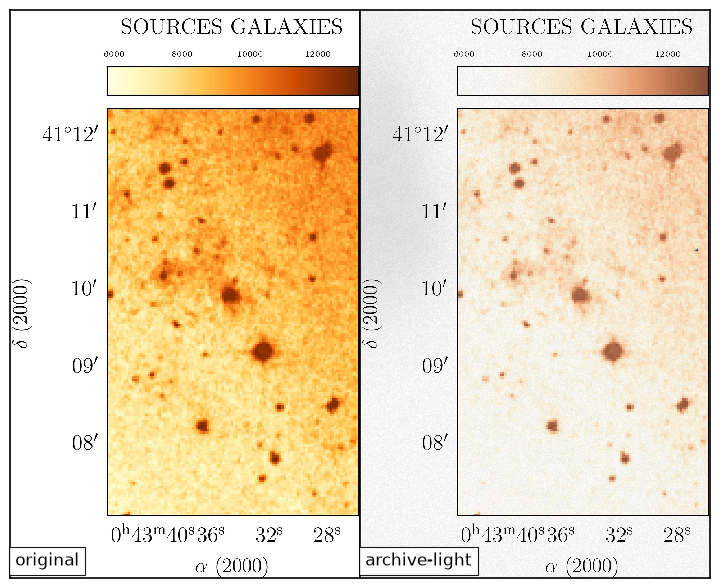

In [23]:
# ---------------- compose ----------------
def pad_to(img, height, width, color=(255, 255, 255)):
    """Centre `img` on a canvas of the given size.  Pads only -- never resizes,
    so not one pixel is resampled."""
    if img.shape[0] == height and img.shape[1] == width:
        return img
    out = np.empty((height, width, img.shape[2]), dtype=img.dtype)
    out[:] = np.asarray(color, dtype=img.dtype)
    y = (height - img.shape[0]) // 2
    x = (width - img.shape[1]) // 2
    out[y:y + img.shape[0], x:x + img.shape[1]] = img
    return out


images = [clean, aged]
if match_panel_size:
    H = max(im.shape[0] for im in images)
    W = max(im.shape[1] for im in images)
    before = [im.shape[1::-1] for im in images]
    images = [pad_to(im, H, W, pad_color) for im in images]
    print('panels padded to a common %dx%d canvas (was %s) -- no resizing'
          % (W, H, ' and '.join(str(b) for b in before)))

panel_labels = labels if labels else [None] * len(images)

# Panels share one edge and keep their own aspect on the other.  Stacked, that
# means a common width and heights from the aspects; side by side, a common
# height and widths from the inverse aspects.
aspects = [im.shape[0] / im.shape[1] for im in images]
gap = row_gap
n = len(images)

if side_by_side:
    widths = [1.0 / a for a in aspects]          # width per unit height
    total = sum(widths) + gap * (n - 1)
    fig_height_in = fig_width_in / total         # one unit of height
    extents = [w / total for w in widths]
else:
    total = sum(aspects) + gap * (n - 1)
    fig_height_in = fig_width_in * total
    extents = [a / total for a in aspects]

def label_placement(corner, inset):
    """(x, y, ha, va) for a label tucked into the named corner of an axes."""
    c = str(corner).lower().replace('-', ' ').replace('_', ' ')
    ha = 'right' if 'right' in c else 'left'
    va = 'top' if 'top' in c else 'bottom'
    return ((1.0 - inset) if ha == 'right' else inset,
            (1.0 - inset) if va == 'top' else inset, ha, va)


lx, ly, lha, lva = label_placement(label_corner, label_inset)
if label_xy is not None:
    lx, ly = label_xy          # explicit position wins; corner still sets the
                               # alignment, so the box grows the sensible way
print('labels: %r corner -> (%.3f, %.3f) ha=%s va=%s' % (label_corner, lx, ly, lha, lva))

fig = plt.figure(figsize=(fig_width_in, fig_height_in))

x, y = 0.0, 1.0
for im, lab, ext in zip(images, panel_labels, extents):
    if side_by_side:
        ax = fig.add_axes([x, 0.0, ext, 1.0])
    else:
        ax = fig.add_axes([0.0, y - ext, 1.0, ext])
    ax.set_xticks([]); ax.set_yticks([])
    # the frame IS the bounding box -- keep the axes on, drop the ticks
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color(border_color)
        spine.set_linewidth(border_width)
    # interpolation='none' is the whole point: matplotlib embeds the image at
    # its ORIGINAL resolution instead of resampling it to the axes size
    ax.imshow(im, interpolation='none', resample=False)
    if lab:
        ax.text(lx, ly, lab, transform=ax.transAxes,
                fontsize=label_fontsize, color=label_color,
                ha=lha, va=lva, bbox=label_boxstyle, zorder=5)
    if side_by_side:
        x += ext + gap / total
    else:
        y -= ext + gap / total

out_pdf = os.path.join(fig_out_dir, out_name.replace('{id}', vqa_id))
fig.savefig(out_pdf, dpi=save_dpi, bbox_inches='tight', pad_inches=0.01)
print('wrote', out_pdf, '(%.1f MB)' % (os.path.getsize(out_pdf) / 1e6))

if also_save_png:
    # dpi chosen so the widest panel lands at its native pixel width
    native_dpi = max(im.shape[1] for im in images) / fig_width_in
    out_png = os.path.splitext(out_pdf)[0] + '.png'
    fig.savefig(out_png, dpi=native_dpi, bbox_inches='tight', pad_inches=0.01)
    print('wrote', out_png, '(%.1f MB, %.0f dpi -> native pixels)'
          % (os.path.getsize(out_png) / 1e6, native_dpi))


In [24]:
# ---------------- check what actually went into the pdf ----------------
# The point of interpolation='none' is that the ORIGINAL pixel counts survive
# into the file.  Read them back out of the pdf rather than assuming.
import re

raw = open(out_pdf, 'rb').read()
embedded = [(int(w), int(h)) for w, h in
            re.findall(rb'/Width (\d+)[^>]*?/Height (\d+)', raw, re.S)]
print('images embedded in the pdf :', embedded)
print('source sizes               :', [im.shape[1::-1] for im in images])
ok = sorted(embedded) == sorted([tuple(im.shape[1::-1]) for im in images])
print('full resolution preserved  :', 'YES' if ok else 'NO -- something resampled')


images embedded in the pdf : [(1127, 1830), (1127, 1830)]
source sizes               : [(1127, 1830), (1127, 1830)]
full resolution preserved  : YES
